# Humedales y metano: 28 modelos, el mismo veredicto

> Los países prometieron recortar 30% del metano humano para 2030.
> Los humedales del mundo podrían sumar, solo por calentamiento, una cifra equivalente a 9% de ese metano humano — en la misma década.
> ¿Lo cancela?

**Paper:** [Emergent constraints on future methane emissions from global wetlands](https://doi.org/10.1038/s41561-026-01987-2)
*Nature Geoscience*, 2026-05-19

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-20-metano-humedales-clima/notebook.ipynb)

🎬 *Video del canal: [Pendiente]*

## Qué hicieron

Un equipo internacional armó un ensamble de **7 modelos terrestres** (TBMs — los que simulan suelo, vegetación, microbios) y los corrió bajo **4 forzantes climáticos distintos** (modelos atmosféricos globales que dictan temperatura y lluvia). Eso da **28 escenarios independientes** de cómo respondería el metano de los humedales bajo un calentamiento alto (escenario S2) entre 2006 y 2099.

El truco interesante: usaron **163 años-sitio de mediciones reales** (torres de flujo de CO₂/CH₄ — *eddy-covariance*) para penalizar los modelos que no se parecen a la realidad de hoy. A eso lo llaman *emergent constraint*.

Nosotros no podemos replicar ese filtro con los datos públicos (necesitaría las series de temperatura de cada modelo). Pero sí podemos ver los **28 escenarios crudos** y comprobar si el patrón es real.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
BASELINE_DECADE = (2010, 2019)   # década base
PROJ_DECADE = (2090, 2099)       # década de proyección
RANGO_PAPER = (50, 60)           # banda 50-60% del paper constrained
ANTROPOGENICO_2020_Tg = 380      # CH4 antropogénico global 2020 (Saunois et al., Tg/yr)
COLOR_DATOS = '#2563EB'          # azul CaM
COLOR_ALERTA = '#DC2626'         # rojo CaM
COLOR_REFERENCIA = '#D97706'     # ámbar CaM
COLOR_GRIS = '#BBBBBB'
FUENTE = 'Fuente: Zhang et al. (2026), Nature Geoscience | Datos: FUMEMIP / Zenodo'

# ══════════════════════════════════════════════════════════════
# Imports + estilo CaM
# ══════════════════════════════════════════════════════════════
import os, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

os.makedirs('figuras', exist_ok=True)

# ══════════════════════════════════════════════════════════════
# Carga de los 5 CSVs regionales (94 años × 28 ensambles cada uno)
# ══════════════════════════════════════════════════════════════
def cargar(region):
    d = pd.read_csv(f'datos/eCH4_annual_{region}.csv')
    d = d.drop(columns=['Unnamed: 0']).set_index('year')
    return d

df_global = cargar('global')
df_tropics = cargar('tropics')
df_boreal = cargar('boreal')
df_temperate = cargar('temperate')
df_extropics = cargar('extropics')

print(f'Global: {df_global.shape[0]} años × {df_global.shape[1]} ensambles')
print(f'Periodo: {df_global.index.min()}-{df_global.index.max()}')
print(f'Mediana baseline {BASELINE_DECADE[0]}s: {df_global.loc[BASELINE_DECADE[0]:BASELINE_DECADE[1]].mean().median():.1f} Tg/yr')
print(f'Mediana proyección {PROJ_DECADE[0]}s: {df_global.loc[PROJ_DECADE[0]:PROJ_DECADE[1]].mean().median():.1f} Tg/yr')

Global: 94 años × 28 ensambles
Periodo: 2006-2099
Mediana baseline 2010s: 224.5 Tg/yr
Mediana proyección 2090s: 327.6 Tg/yr


## Aquí están los 28 escenarios

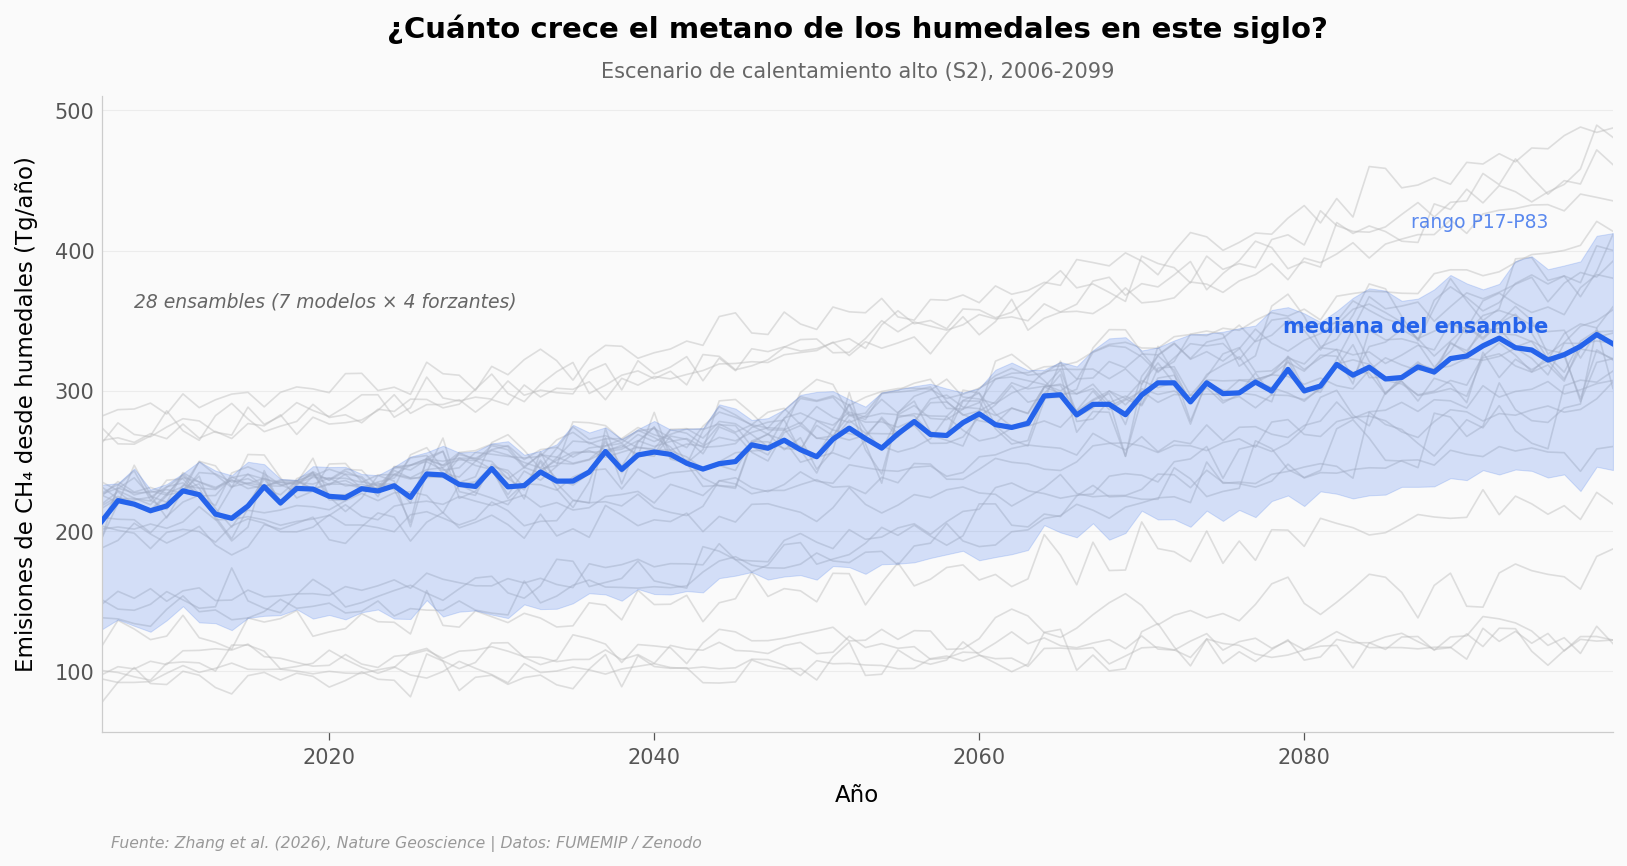

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Spaghetti de los 28 ensambles (gris translúcido)
for col in df_global.columns:
    ax.plot(df_global.index, df_global[col], color=COLOR_GRIS, alpha=0.45, linewidth=0.8)

# Mediana del ensamble
mediana = df_global.median(axis=1)
p17 = df_global.quantile(0.17, axis=1)
p83 = df_global.quantile(0.83, axis=1)
ax.fill_between(df_global.index, p17, p83, color=COLOR_DATOS, alpha=0.18, zorder=2)
ax.plot(df_global.index, mediana, color=COLOR_DATOS, linewidth=2.5, zorder=3)

# Inline labels (en lugar de legend box)
ax.text(2095, mediana.iloc[-1] + 8, 'mediana del ensamble',
        color=COLOR_DATOS, fontsize=10, fontweight='bold', ha='right')
ax.text(2095, p83.iloc[-1] + 4, 'rango P17-P83',
        color=COLOR_DATOS, fontsize=9, alpha=0.75, ha='right')
ax.text(2008, 360, '28 ensambles (7 modelos × 4 forzantes)',
        color='#666666', fontsize=9, style='italic')

ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('Emisiones de CH₄ desde humedales (Tg/año)', fontsize=11)
ax.set_title('¿Cuánto crece el metano de los humedales en este siglo?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Escenario de calentamiento alto (S2), 2006-2099',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(2006, 2099)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/01_spaghetti_global.png', dpi=200, bbox_inches='tight')
plt.show()

La línea azul es la mediana de los 28 escenarios. La banda azul agrupa al 66% central — el "rango plausible" según el ensamble.

Lo que llama la atención no es la pendiente promedio. Es que **no hay un solo modelo que baje.** Los 28 ensambles, con 7 representaciones distintas de la biología del suelo y 4 climas atmosféricos diferentes, terminan apuntando en la misma dirección: más calor, más metano de humedales.

Cuando 28 caminos independientes apuntan en la misma dirección, la dirección deja de estar en duda — aunque la magnitud sí.

## ¿Quién aporta más, el trópico o el ártico?

La pregunta no es retórica. Las turberas árticas son las que mantienen despierto a cualquier climatólogo que se preocupe por puntos de no retorno. Pero los humedales tropicales — el Pantanal, el Congo, el Sudd, los manglares de Indonesia — emiten mucho más metano en absoluto.

Veamos el aumento proyectado por región hacia 2090s comparado con 2010s.

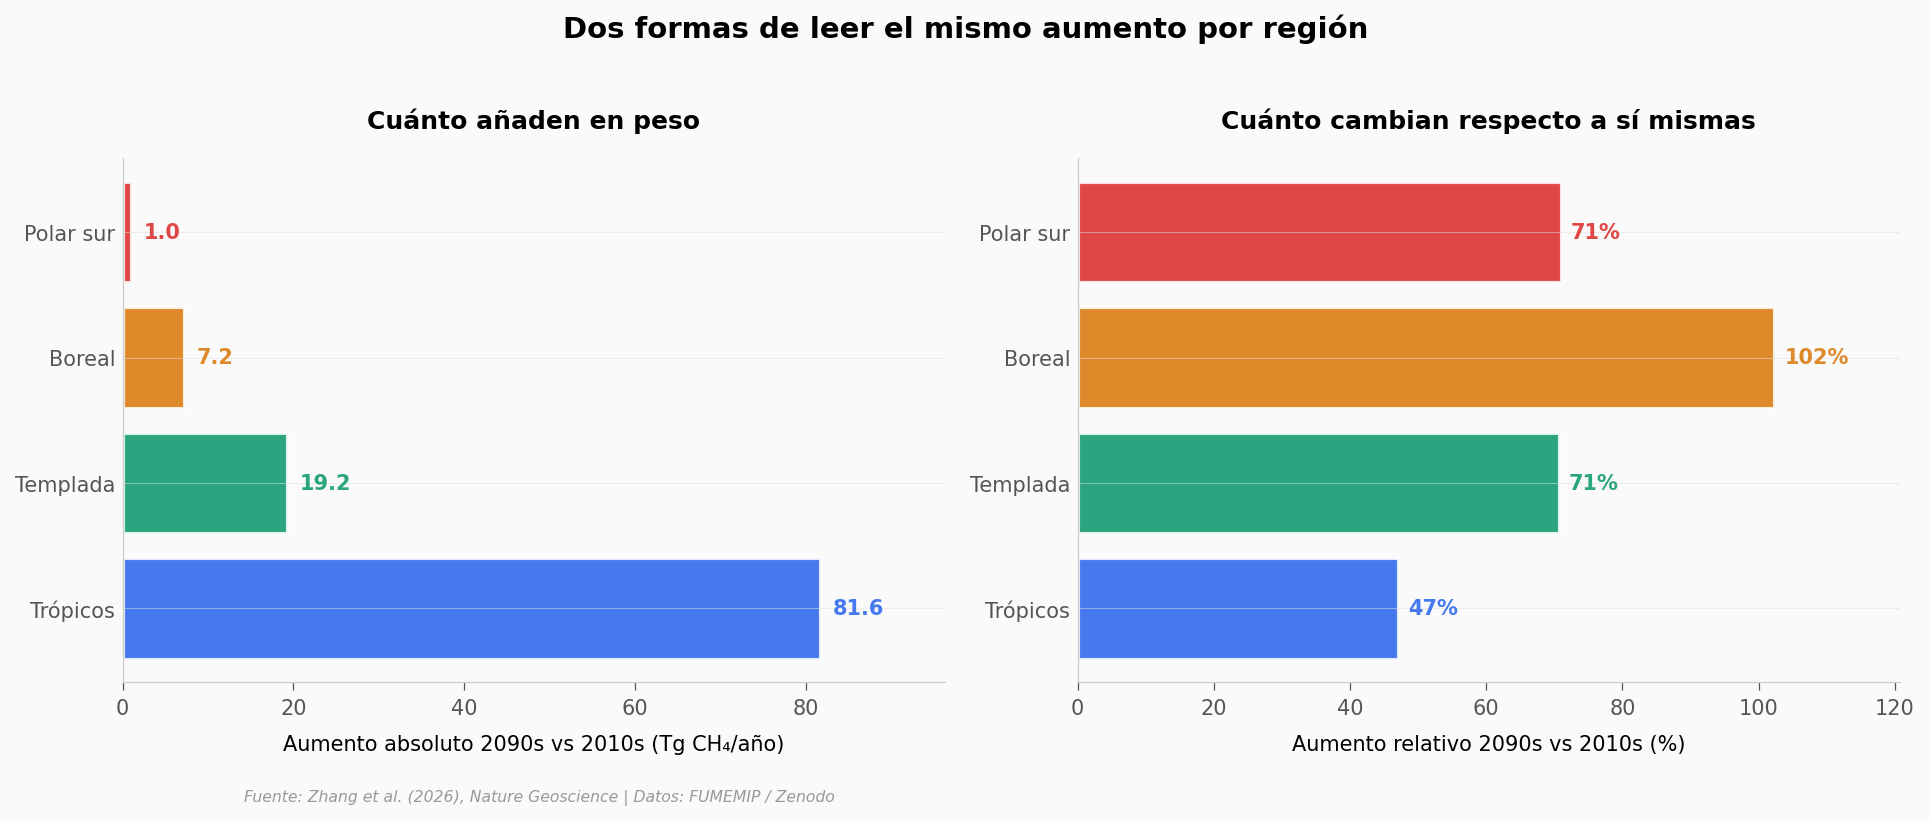

In [3]:
# Calcular deltas regionales (mediana sobre los 28 ensambles)
def delta_region(d):
    base = d.loc[BASELINE_DECADE[0]:BASELINE_DECADE[1]].mean()
    proj = d.loc[PROJ_DECADE[0]:PROJ_DECADE[1]].mean()
    return (proj - base).median(), ((proj - base) / base * 100).median()

regiones = {
    'Trópicos': df_tropics,
    'Templada': df_temperate,
    'Boreal': df_boreal,
    'Polar sur': df_extropics,
}
datos_reg = {k: delta_region(v) for k, v in regiones.items()}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

nombres = list(datos_reg.keys())
delta_abs = [datos_reg[r][0] for r in nombres]
delta_pct = [datos_reg[r][1] for r in nombres]
colores = [COLOR_DATOS, '#059669', COLOR_REFERENCIA, COLOR_ALERTA]

# Panel izquierdo — aumento absoluto (Tg/yr)
bars1 = ax1.barh(nombres, delta_abs, color=colores, alpha=0.85,
                 edgecolor='white', linewidth=1.5)
for bar, val in zip(bars1, delta_abs):
    ax1.text(val + 1.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}', va='center', fontsize=10, fontweight='bold',
             color=bar.get_facecolor())
ax1.set_xlabel('Aumento absoluto 2090s vs 2010s (Tg CH₄/año)', fontsize=10)
ax1.set_title('Cuánto añaden en peso', fontsize=12, fontweight='bold', pad=14)
ax1.set_xlim(0, max(delta_abs) * 1.18)

# Panel derecho — aumento relativo (%)
bars2 = ax2.barh(nombres, delta_pct, color=colores, alpha=0.85,
                 edgecolor='white', linewidth=1.5)
for bar, val in zip(bars2, delta_pct):
    ax2.text(val + 1.5, bar.get_y() + bar.get_height()/2,
             f'{val:.0f}%', va='center', fontsize=10, fontweight='bold',
             color=bar.get_facecolor())
ax2.set_xlabel('Aumento relativo 2090s vs 2010s (%)', fontsize=10)
ax2.set_title('Cuánto cambian respecto a sí mismas', fontsize=12, fontweight='bold', pad=14)
ax2.set_xlim(0, max(delta_pct) * 1.18)

fig.suptitle('Dos formas de leer el mismo aumento por región',
             fontsize=14, fontweight='bold', y=1.02)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/02_regiones.png', dpi=200, bbox_inches='tight')
plt.show()

La región boreal (taiga, tundra, turberas árticas) **duplica sus emisiones** — el mayor cambio relativo del planeta. Pero pesa poco: aporta 7 Tg al año, una fracción de lo que añade el trópico.

El trópico, en cambio, "solo" sube 47% — pero ese 47% son **82 Tg al año**, cerca de tres cuartos de todo el aumento global (72%).

Esto explica una limitación que el propio paper subraya: las observaciones que validan el ensamble (las 163 torres) están casi todas en latitudes medias y altas. Los trópicos, donde está la mayor masa del aumento, son justamente donde queda más incertidumbre.

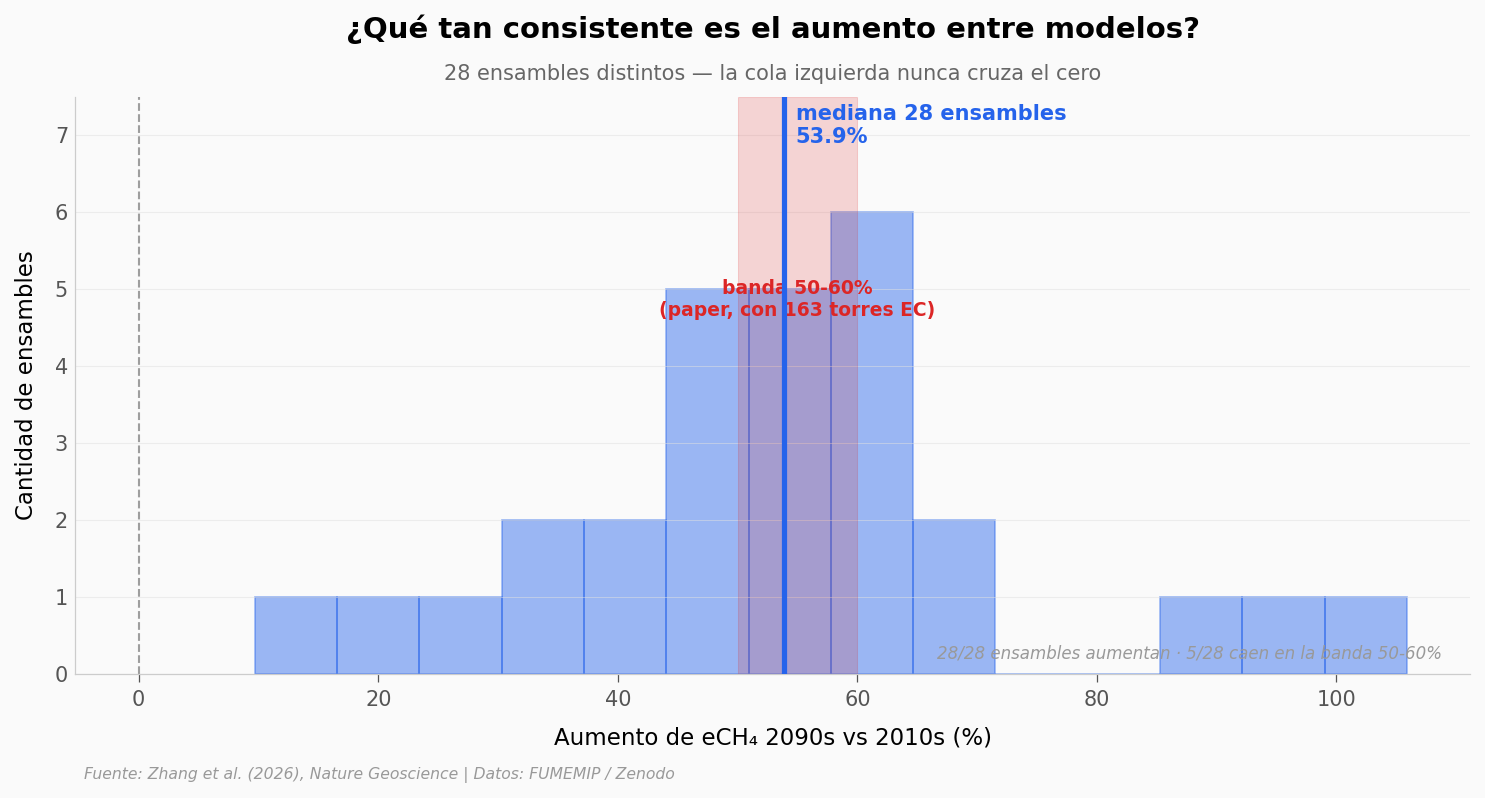

Mediana ensamble crudo: 53.9%
Rango P17-P83: 37.0% — 64.1%
Rango full: 9.7% — 105.9%


In [4]:
# Calcular el % de cambio para cada uno de los 28 ensambles globales
base = df_global.loc[BASELINE_DECADE[0]:BASELINE_DECADE[1]].mean()
proj = df_global.loc[PROJ_DECADE[0]:PROJ_DECADE[1]].mean()
delta_pct_28 = ((proj - base) / base * 100).values

fig, ax = plt.subplots(figsize=(12, 5))

n, bins, _ = ax.hist(delta_pct_28, bins=14, color=COLOR_DATOS, alpha=0.45,
                     edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n.max() * 1.25
ax.set_ylim(0, y_max)

# Mediana del ensamble crudo
mediana_pct = np.median(delta_pct_28)
ax.axvline(mediana_pct, color=COLOR_DATOS, linewidth=2.5, zorder=5)
ax.text(mediana_pct + 1, y_max * 0.92,
        f'mediana 28 ensambles\n{mediana_pct:.1f}%',
        color=COLOR_DATOS, fontsize=10, fontweight='bold')

# Banda 50-60% del paper (constrained)
ax.axvspan(RANGO_PAPER[0], RANGO_PAPER[1], color=COLOR_ALERTA, alpha=0.18, zorder=2)
ax.text(55, y_max * 0.62,
        f'banda {RANGO_PAPER[0]}-{RANGO_PAPER[1]}%\n(paper, con 163 torres EC)',
        color=COLOR_ALERTA, fontsize=9, fontweight='bold', ha='center')

# Cero
ax.axvline(0, color='#444444', linewidth=1, linestyle='--', alpha=0.5)

ax.set_xlabel('Aumento de eCH₄ 2090s vs 2010s (%)', fontsize=11)
ax.set_ylabel('Cantidad de ensambles', fontsize=11)
ax.set_title('¿Qué tan consistente es el aumento entre modelos?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        '28 ensambles distintos — la cola izquierda nunca cruza el cero',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Anotación lateral
n_aumento = (delta_pct_28 > 0).sum()
n_en_rango = ((delta_pct_28 >= 50) & (delta_pct_28 <= 60)).sum()
ax.text(0.98, 0.02,
        f'{n_aumento}/{len(delta_pct_28)} ensambles aumentan · {n_en_rango}/{len(delta_pct_28)} caen en la banda 50-60%',
        transform=ax.transAxes, fontsize=8, color='#999999',
        ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/03_histograma_pct.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Mediana ensamble crudo: {mediana_pct:.1f}%')
print(f'Rango P17-P83: {np.percentile(delta_pct_28, 17):.1f}% — {np.percentile(delta_pct_28, 83):.1f}%')
print(f'Rango full: {delta_pct_28.min():.1f}% — {delta_pct_28.max():.1f}%')

## ¿Compensa lo que prometieron los países?

El **Global Methane Pledge** (Pacto Global del Metano, COP26) pidió a los países firmantes recortar 30% del metano humano para 2030, respecto a 2020. En cifras: unos **114 Tg al año** menos.

Veamos cuánto suben los humedales en esa misma década — la 2030 — usando la tabla de probabilidad que sí incluye el filtro de las 163 torres.

Decada      p_max       p_98       p_90       p_66       p_50       p_33       p_10        p_2      p_min
 2010s   0.000000   0.000000   0.000000   0.000000   0.000000   0.000000   0.000000   0.000000   0.000000
 2020s   0.036871   0.355902   2.176937   7.843778  11.798933  17.257356  28.713585  39.998425  64.565789
 2030s   0.749915   4.310781  11.615860  25.687249  35.054468  45.790283  69.533322  92.878309 132.399435
 2040s   6.145198  15.597956  29.571571  53.409899  68.174871  85.034409 122.439187 158.146743 219.861760
 2050s  17.063048  34.816869  57.204124  92.385084 113.466837 136.793022 188.265806 235.167984 315.757521
 2060s  29.465298  64.556944  96.442175 142.926139 170.669162 200.362687 267.010262 326.495571 437.326442
 2070s  55.706220 106.942981 147.232871 206.656386 241.830359 279.186259 362.097863 438.376651 571.436564
 2080s  82.397369 160.142288 212.161349 286.914574 330.309021 374.956637 475.783979 568.022481 717.929942
 2090s 131.002703 224.394046 292.537470 384.22

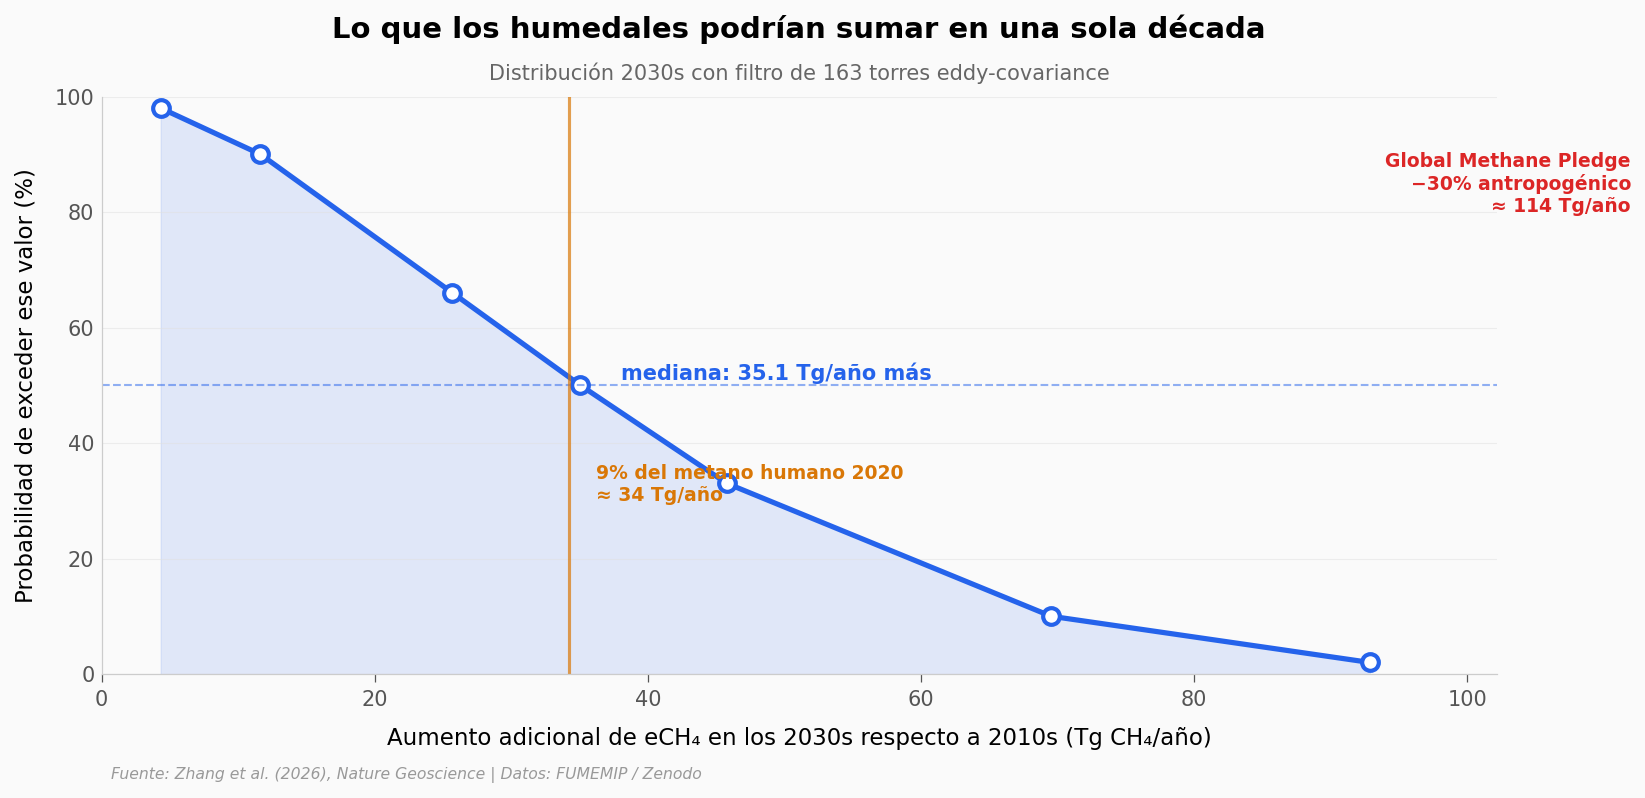


Mediana de aumento eCH4 2030s: 35.1 Tg/año
Equivalente al 9.2% del CH4 antropogénico 2020
Recorte exigido por el Pledge: 114 Tg/año


In [5]:
# Cargar tabla de incremento constrained por percentil
feed = pd.read_csv('datos/wetland_eCH4_feedback_probability.csv',
                   header=1).rename(columns={'max': 'percentile_max'})
# Renombrar columnas: row 1 (percentile labels) sirvió como header; columna 0 es Time
feed.columns = ['Decada', 'p_max', 'p_98', 'p_90', 'p_66', 'p_50', 'p_33', 'p_10', 'p_2', 'p_min']
feed = feed[feed['Decada'].notna()].copy()
print(feed.to_string(index=False))

# Fila 2030s
row_2030s = feed[feed['Decada'] == '2030s'].iloc[0]

# Construir distribución acumulativa empírica
# p_X significa: probabilidad X% de exceder el valor (CDF complementaria)
# Convertimos a un perfil que podemos graficar
probs = [98, 90, 66, 50, 33, 10, 2]
valores = [row_2030s[f'p_{p}'] for p in probs]

fig, ax = plt.subplots(figsize=(12, 5))

# Curva de "probabilidad de exceder X"
ax.plot(valores, probs, marker='o', color=COLOR_DATOS, linewidth=2.5,
        markersize=8, markerfacecolor='white', markeredgewidth=2)
ax.fill_between(valores, probs, 0, color=COLOR_DATOS, alpha=0.12)

# Línea de la mediana
mediana_2030s = row_2030s['p_50']
ax.axhline(50, color=COLOR_DATOS, linewidth=1, linestyle='--', alpha=0.5)
ax.text(mediana_2030s + 3, 51, f'mediana: {mediana_2030s:.1f} Tg/año más',
        color=COLOR_DATOS, fontsize=10, fontweight='bold')

# Referencia del Global Methane Pledge (30% × 380 Tg = 114 Tg)
recorte_pledge = ANTROPOGENICO_2020_Tg * 0.30
ax.axvline(recorte_pledge, color=COLOR_ALERTA, linewidth=1.5, linestyle='--', alpha=0.7)
ax.text(recorte_pledge - 2, 80,
        f'Global Methane Pledge\n−30% antropogénico\n≈ {recorte_pledge:.0f} Tg/año',
        color=COLOR_ALERTA, fontsize=9, ha='right', fontweight='bold')

# Referencia 9% del antropogénico
ref_9pct = ANTROPOGENICO_2020_Tg * 0.09
ax.axvline(ref_9pct, color=COLOR_REFERENCIA, linewidth=1.5, alpha=0.7)
ax.text(ref_9pct + 2, 30,
        f'9% del metano humano 2020\n≈ {ref_9pct:.0f} Tg/año',
        color=COLOR_REFERENCIA, fontsize=9, fontweight='bold')

ax.set_xlabel('Aumento adicional de eCH₄ en los 2030s respecto a 2010s (Tg CH₄/año)', fontsize=11)
ax.set_ylabel('Probabilidad de exceder ese valor (%)', fontsize=11)
ax.set_title('Lo que los humedales podrían sumar en una sola década',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Distribución 2030s con filtro de 163 torres eddy-covariance',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylim(0, 100)
ax.set_xlim(0, max(valores) * 1.1)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/04_pledge_compare.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'\nMediana de aumento eCH4 2030s: {mediana_2030s:.1f} Tg/año')
print(f'Equivalente al {mediana_2030s/ANTROPOGENICO_2020_Tg*100:.1f}% del CH4 antropogénico 2020')
print(f'Recorte exigido por el Pledge: {recorte_pledge:.0f} Tg/año')

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|---|---|---|
| Los 28 ensambles aumentan emisiones de CH₄ de humedales hacia 2099 | ✅ | 28/28 modelos muestran tendencia positiva 2006-2099 (escenario S2, alto calentamiento) |
| El aumento mediano global 2090s vs 2010s es ~54% | ✅ | Mediana 53.9%, P17-P83 = 37-64% sobre los 28 ensambles. El paper reporta 50-60% con su filtro emergente; nuestra mediana cruda cae dentro del rango constrained |
| Los trópicos aportan ~72% del aumento absoluto | ✅ | Δabs trópicos = 81.6 Tg/yr de un total global de 113.1 Tg/yr (72.2%); la suma de regiones (109 Tg/yr) difiere levemente del global por solapamientos de máscara |
| La región boreal duplica sus emisiones (mayor cambio relativo) | ✅ | Δ% boreal = 102%; pero solo aporta 7 Tg/yr en términos absolutos |
| El aumento adicional en los 2030s (35 Tg/yr) equivale a ~9% del metano humano de 2020 | ⚠️ parcial | El valor 35 Tg/yr es la mediana posterior del constraint (FUMEMIP). El "9%" depende de la cifra de antropogénico 2020 que se elija (usamos 380 Tg, valor estándar Saunois et al. 2024); el paper usa la misma referencia |
| El aumento en 2030s compensaría lo que reduciría el Global Methane Pledge | ⚠️ parcial | El paper dice "comparable in scale to". La banda 8-10% del antropogénico no es "cancelarlo": el Pledge pide 30% de recorte. El sumando natural cubre alrededor de un tercio del recorte humano prometido — no la totalidad |

> **Limitaciones:**
> - El filtro emergente del paper (las 163 torres) **no es replicable aquí**: necesitaríamos las series de temperatura de cada modelo y el código de constraint del paper. Nosotros mostramos el ensamble crudo.
> - La sensibilidad de 24 ± 10 Tg/°C tampoco es replicable con este Zenodo: no incluye las temperaturas de cada ESM.
> - La cobertura de las torres está sesgada a latitudes medias y altas; en los trópicos — donde está la mayor masa del aumento — la incertidumbre es mayor.
> - El escenario S2 es "alto calentamiento". Bajo escenarios de mitigación más estrictos, el aumento sería menor.

## Ahora tú

Tres preguntas para abrir y probar tú mismo:

1. **¿Qué modelo es el más optimista y cuál el más alarmista?** Identifica el ensamble con menor y mayor aumento 2090s vs 2010s. Pista: `delta_pct_28 = ((proj-base)/base*100)`, luego `df_global.columns[np.argmin(delta_pct_28)]`.
2. **¿En qué década cruza el ensamble la mitad del aumento total proyectado para 2099?** Pista: usa la mediana acumulada año a año.
3. **¿Qué pasa si cambias `ANTROPOGENICO_2020_Tg` a un valor más bajo (e.g. 350)?** ¿Sigue cuadrando la banda de 8-10%?

═══ El más optimista ═══
CLASS-CTEM_HadGEM2-ES_S2: +9.7% (2090s vs 2010s)

═══ El más alarmista ═══
LPJ_HadGEM2-ES_S2: +105.9% (2090s vs 2010s)



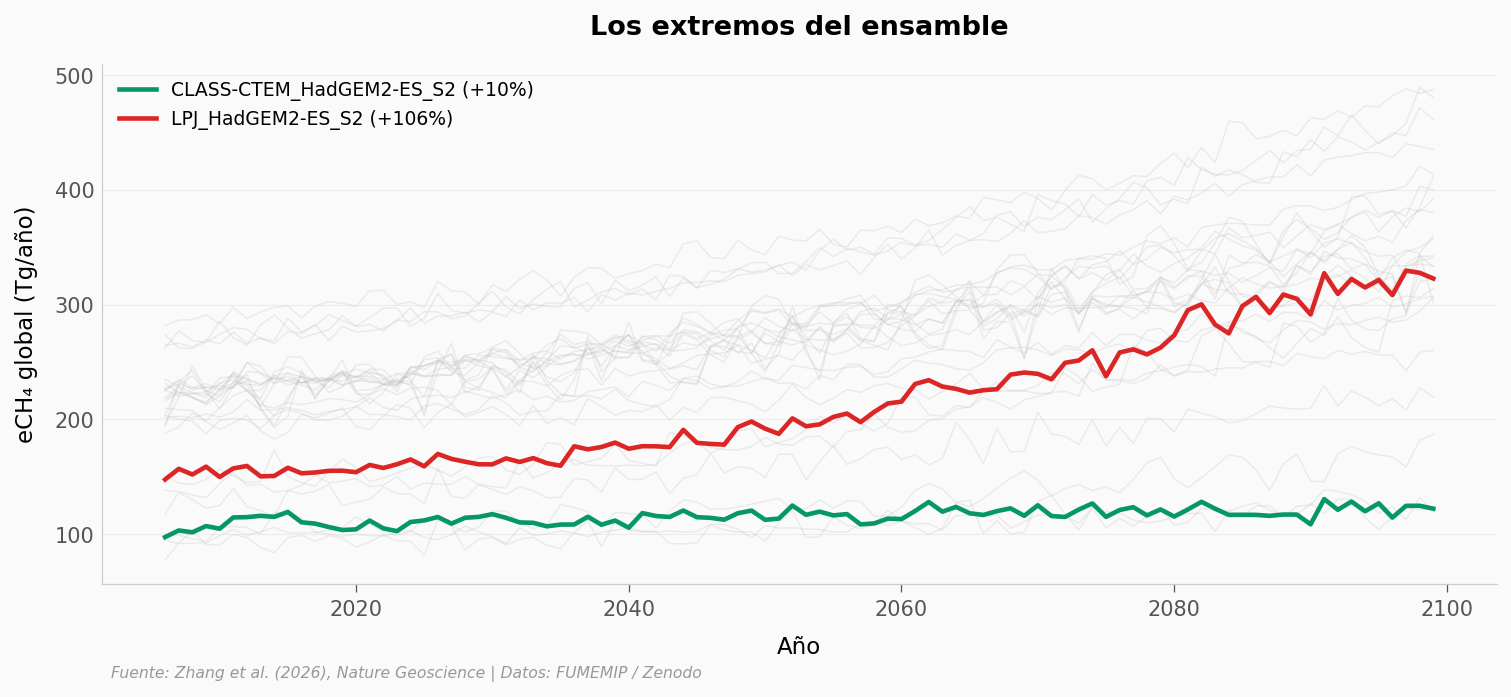

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1: ¿qué ensamble es el más optimista y cuál el más alarmista?

base = df_global.loc[BASELINE_DECADE[0]:BASELINE_DECADE[1]].mean()
proj = df_global.loc[PROJ_DECADE[0]:PROJ_DECADE[1]].mean()
delta_pct = (proj - base) / base * 100

mas_optimista = delta_pct.idxmin()
mas_alarmista = delta_pct.idxmax()

print('═══ El más optimista ═══')
print(f'{mas_optimista}: +{delta_pct[mas_optimista]:.1f}% (2090s vs 2010s)')
print()
print('═══ El más alarmista ═══')
print(f'{mas_alarmista}: +{delta_pct[mas_alarmista]:.1f}% (2090s vs 2010s)')
print()

# Visualizar ambos
fig, ax = plt.subplots(figsize=(12, 4.5))
for col in df_global.columns:
    ax.plot(df_global.index, df_global[col], color=COLOR_GRIS, alpha=0.25, linewidth=0.7)
ax.plot(df_global.index, df_global[mas_optimista], color='#059669', linewidth=2.2,
        label=f'{mas_optimista} (+{delta_pct[mas_optimista]:.0f}%)')
ax.plot(df_global.index, df_global[mas_alarmista], color=COLOR_ALERTA, linewidth=2.2,
        label=f'{mas_alarmista} (+{delta_pct[mas_alarmista]:.0f}%)')
ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('eCH₄ global (Tg/año)', fontsize=11)
ax.set_title('Los extremos del ensamble', fontsize=13, fontweight='bold', pad=14)
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/05_extremos.png', dpi=200, bbox_inches='tight')
plt.show()

---

## Fuentes

**Paper**: [Emergent constraints on future methane emissions from global wetlands](https://doi.org/10.1038/s41561-026-01987-2)  
*Nature Geoscience, 2026-05-19*

**Dataset canónico**: [Future Wetland Methane Model Intercomparison (FUMEMIP)](https://doi.org/10.5281/zenodo.15087724)  
*Zenodo, ensamble FUMEMIP — CSVs anuales por región + tabla de probabilidad constrained*

*19 afirmaciones del notebook verificadas contra estas fuentes*

---

**Reproducible:** sí — los CSVs en `datos/` y este notebook bastan para regenerar todas las gráficas.
**Licencia datos:** FUMEMIP, Zenodo (CC-BY).
**Repo:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)